# 19. Planetary rover module activation over a battery budget (temporal Case 2)

This example addresses the question "robots with modules that switch on and off depending on context", solved as a genuine dynamic program with a resource carried between stages. A small planetary rover carries modules that can be independently activated: a drive train, a science payload, a high-gain comms link, and a survival heater. Each mission phase demands a capability, and the rover runs on a battery that depletes when modules draw power and partially recharges from solar input between phases.

The outer object is a finite-horizon DP over mission phases; the per-phase decision is which module configuration (which "mode") to activate; the per-phase cost is obtained by *solving a co-design problem* that sizes the power bus and accumulates the mode's energy and objective cost; and the battery state of charge is the carried state linking phases. The framing follows standard spacecraft power-mode practice, where the power budget is organised into operational modes entered during different mission phases, and activities are scheduled around available battery reserve.


## Imports and module load

In [1]:
import importlib.util, os, sys
PROJECT_ROOT = os.path.abspath('.')
sys.path.insert(0, PROJECT_ROOT)

_spec = importlib.util.spec_from_file_location(
    'rover', os.path.join(PROJECT_ROOT, 'examples', '19_rover_modules.py'))
ex19 = importlib.util.module_from_spec(_spec)
_spec.loader.exec_module(ex19)

from codesign import solve_dynamic, rollout
print("Modes:", ", ".join(a.name for a in ex19.ALL_MODES))
print(f"Battery capacity {ex19.BATTERY_CAPACITY_WH:.0f} Wh, "
      f"solar recharge {ex19.SOLAR_RECHARGE_WH:.0f} Wh/phase")


Modes: drive, science, comms, survival
Battery capacity 300 Wh, solar recharge 60 Wh/phase


## The four modes, as an energy/value trade

Each mode is a co-design problem that, given the phase's capability demand, sizes a power bus and returns the energy drawn (subtracted from the battery) and a cost. The cost is *energy spent plus an opportunity penalty* for objective value not delivered, kept non-negative because the co-design resource poset forbids negative resources. High-value modes carry a low penalty and are preferred when charge allows.


In [2]:
from codesign import solve, minimize_cost
rows = []
for arch in ex19.ALL_MODES:
    res = solve(arch.dp, {"cap": 5.0})
    pt = minimize_cost(res, ex19.mission_cost) if res.feasible else None
    if pt:
        rows.append((arch.name, pt["energy_Wh"], pt["cost"]))
print(f"{'mode':<9} {'energy_Wh':>10} {'cost':>8}")
for name, e, c in rows:
    print(f"{name:<9} {e:>10.1f} {c:>8.1f}")


mode       energy_Wh     cost
drive           75.0    165.0
science        115.0    115.0
comms           73.0    153.0
survival        19.0    219.0


## Solve the policy and roll out from full and depleted batteries

`solve_dynamic` runs the backward Bellman pass over the (phase, state-of-charge) lattice and returns a full state-indexed policy, valid for any starting charge. We roll it out from a full battery and from a nearly-empty one.


In [3]:
stages = ex19.build_mission(n_phases=6)
grid = ex19.StateGrid.linspace(0.0, ex19.BATTERY_CAPACITY_WH, 61)
policy = solve_dynamic(stages, grid, cost_fn=ex19.mission_cost,
                       terminal_cost=ex19.terminal_reward)

full = rollout(policy, stages, ex19.BATTERY_CAPACITY_WH)
low  = rollout(policy, stages, 90.0)

for label, res in (("full 300 Wh", full), ("low 90 Wh", low)):
    print(f"\n{label}: {' -> '.join(res.schedule)}  (cost {res.total_cost:.1f})")
    for sr in res.stages:
        print(f"   {sr.stage:<8s} {sr.architecture:<9s} "
              f"soc {sr.state_in:6.1f} -> {sr.state_out:6.1f} Wh")



full 300 Wh: science -> science -> science -> science -> science -> comms  (cost 727.5)
   phase_1  science   soc  300.0 ->  245.0 Wh
   phase_2  science   soc  245.0 ->  190.0 Wh
   phase_3  science   soc  190.0 ->  135.0 Wh
   phase_4  science   soc  135.0 ->   80.0 Wh
   phase_5  science   soc   80.0 ->   25.0 Wh
   phase_6  comms     soc   25.0 ->   10.0 Wh

low 90 Wh: comms -> comms -> comms -> comms -> comms -> comms  (cost 918.0)
   phase_1  comms     soc   90.0 ->   75.0 Wh
   phase_2  comms     soc   75.0 ->   60.0 Wh
   phase_3  comms     soc   60.0 ->   45.0 Wh
   phase_4  comms     soc   45.0 ->   30.0 Wh
   phase_5  comms     soc   30.0 ->   15.0 Wh
   phase_6  comms     soc   15.0 ->    0.0 Wh


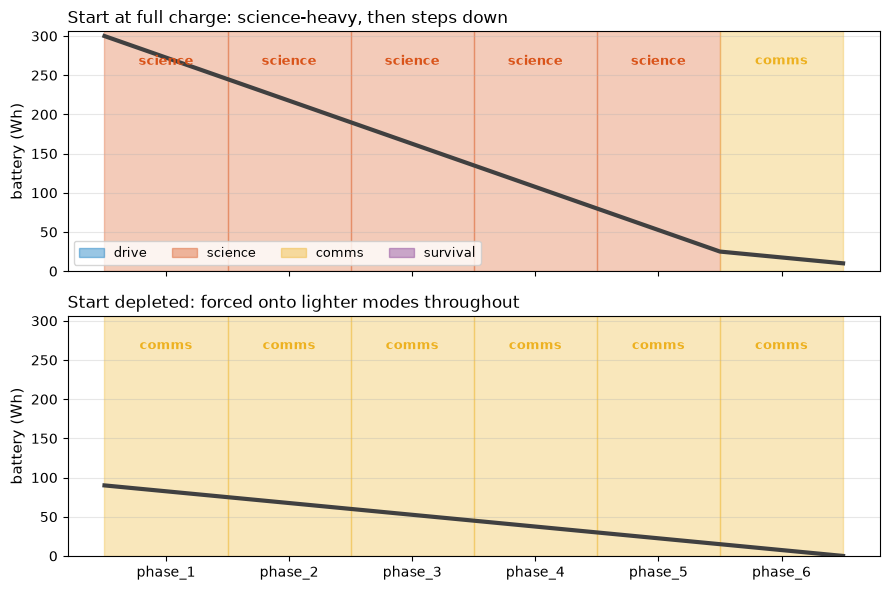

In [4]:
import matplotlib.pyplot as plt

# MATLAB gem colours, one per mode.
MODE_COLOR = {"drive": "#0072BD", "science": "#D95319",
              "comms": "#EDB120", "survival": "#7E2F8E"}

fig, axes = plt.subplots(2, 1, figsize=(9, 6), sharex=True)

def plot_run(ax, res, title):
    trace_x, trace_y = [], []
    for i, s in enumerate(res.stages):
        trace_x += [i, i + 1]
        trace_y += [s.state_in, s.state_out]
    ax.plot(trace_x, trace_y, color="0.25", lw=3.0, zorder=3,
            label="state of charge")
    for i, s in enumerate(res.stages):
        ax.axvspan(i, i + 1, color=MODE_COLOR.get(s.architecture, "0.6"),
                   alpha=0.30, zorder=1)
        ax.text(i + 0.5, ex19.BATTERY_CAPACITY_WH * 0.92, s.architecture,
                ha="center", va="top", fontsize=9,
                color=MODE_COLOR.get(s.architecture, "0.3"), fontweight="bold")
    ax.set_ylim(0, ex19.BATTERY_CAPACITY_WH * 1.02)
    ax.set_ylabel("battery (Wh)", fontsize=11)
    ax.set_title(title, fontsize=12, loc="left")
    ax.grid(True, axis="y", alpha=0.3, linewidth=0.8)

plot_run(axes[0], full, "Start at full charge: science-heavy, then steps down")
plot_run(axes[1], low, "Start depleted: forced onto lighter modes throughout")
axes[1].set_xticks([i + 0.5 for i in range(len(full.stages))])
axes[1].set_xticklabels([s.stage for s in full.stages], fontsize=10)
from matplotlib.patches import Patch
axes[0].legend(handles=[Patch(color=c, alpha=0.4, label=m)
                        for m, c in MODE_COLOR.items()],
               loc="lower left", fontsize=9, ncol=4, frameon=True)
fig.tight_layout()
plt.show()


## What the policy reveals

The same policy produces two different module-activation schedules depending only on the starting charge. From a full battery the rover runs the high-value science mode until reserve falls, then steps down to a lighter mode as the battery approaches empty. Starting depleted, it can never afford science's large draw (which would take the battery negative), so it holds a lighter mode throughout and lets solar rebuild what it can.

This is the load-shedding behaviour real power-constrained missions use, and it falls out of the framework without any special-casing: the co-design solve sizes each mode, the carried state of charge couples the phases, and the backward DP finds the schedule. The out-of-bounds guard in the solver is what makes it correct, a mode whose draw would take the battery below zero is rejected before the grid snaps the state back into range, so the rover never plans a schedule it cannot energetically execute.
